# Faizaan Ali | HW5 | Task 2


## Data

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Dataset shape: (400, 64, 64, 1)


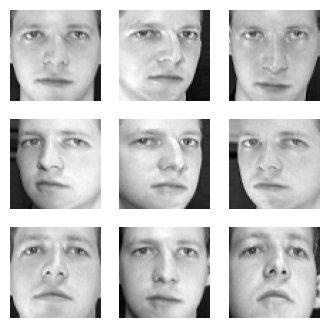

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_olivetti_faces

faces = fetch_olivetti_faces()

# VAE dataset (0-1)
X_vae = faces.images[..., None]

# GAN dataset (-1,1)
X_gan = (faces.images[..., None] - 0.5) * 2.0

BATCH = 32

dataset_vae = tf.data.Dataset.from_tensor_slices(X_vae).shuffle(400).batch(BATCH)
dataset_gan = tf.data.Dataset.from_tensor_slices(X_gan).shuffle(400).batch(BATCH)

print("Dataset shape:", X_vae.shape)

# visualize
plt.figure(figsize=(4,4))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_vae[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.show()

The Olivetti is a fairly small human face dataset. It is comprised of 400 images, 10 images for each of its 40 subjects. The subjects' photos were taken at different angles, expressions, and lighting to add some variance. Each image is 64x64 pixels with 256 grey levels stored as 8-bit integers. This dataset represents a classification challenge in determining the subject id 0-39.

## VAE

In [ ]:
LATENT = 32

class VAE(tf.keras.Model):
    def __init__(self):
        super().__init__()

        self.encoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer((64,64,1)),
            tf.keras.layers.Conv2D(32,3,2,activation="relu"),
            tf.keras.layers.Conv2D(64,3,2,activation="relu"),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(LATENT*2)
        ])

        self.decoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer((LATENT,)),
            tf.keras.layers.Dense(16*16*64,activation="relu"),
            tf.keras.layers.Reshape((16,16,64)),
            tf.keras.layers.Conv2DTranspose(64,3,2,padding="same",activation="relu"),
            tf.keras.layers.Conv2DTranspose(32,3,2,padding="same",activation="relu"),
            tf.keras.layers.Conv2DTranspose(1,3,padding="same")
        ])

    def encode(self,x):
        m,lv=tf.split(self.encoder(x),2,axis=1)
        return m,lv

    def reparam(self,m,lv):
        eps=tf.random.normal(m.shape)
        return eps*tf.exp(lv*0.5)+m

    def decode(self,z):
        return self.decoder(z)

VAE Epoch 0 Loss 2835.3462
VAE Epoch 1 Loss 2829.0117
VAE Epoch 2 Loss 2828.6128
VAE Epoch 3 Loss 2817.8179
VAE Epoch 4 Loss 2783.5715
VAE Epoch 5 Loss 2791.8467
VAE Epoch 6 Loss 2753.5105
VAE Epoch 7 Loss 2750.5771
VAE Epoch 8 Loss 2745.4893
VAE Epoch 9 Loss 2781.676
VAE Epoch 10 Loss 2762.6948
VAE Epoch 11 Loss 2758.7502
VAE Epoch 12 Loss 2741.4917
VAE Epoch 13 Loss 2763.2676
VAE Epoch 14 Loss 2702.3809
VAE Epoch 15 Loss 2709.314
VAE Epoch 16 Loss 2757.421
VAE Epoch 17 Loss 2714.1743
VAE Epoch 18 Loss 2735.1416
VAE Epoch 19 Loss 2722.1294
VAE Epoch 20 Loss 2720.0728
VAE Epoch 21 Loss 2733.7078
VAE Epoch 22 Loss 2770.63
VAE Epoch 23 Loss 2721.8135
VAE Epoch 24 Loss 2753.871
VAE Epoch 25 Loss 2716.3716
VAE Epoch 26 Loss 2723.1692
VAE Epoch 27 Loss 2743.9287
VAE Epoch 28 Loss 2728.1506
VAE Epoch 29 Loss 2702.5476
VAE Epoch 30 Loss 2706.5745
VAE Epoch 31 Loss 2730.9373
VAE Epoch 32 Loss 2694.0293
VAE Epoch 33 Loss 2682.661
VAE Epoch 34 Loss 2677.1528
VAE Epoch 35 Loss 2682.2766
VAE Epoch

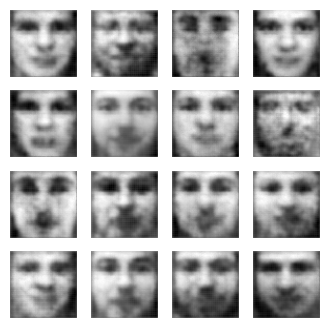

In [ ]:
model=VAE()
opt=tf.keras.optimizers.Adam(1e-4)

def loss(model,x):
    m,lv=model.encode(x)
    z=model.reparam(m,lv)
    x_hat=model.decode(z)

    recon=tf.nn.sigmoid_cross_entropy_with_logits(labels=x,logits=x_hat)
    recon=tf.reduce_sum(recon,[1,2,3])

    kl=-0.5*tf.reduce_sum(1+lv-m**2-tf.exp(lv),1)

    return tf.reduce_mean(recon+kl)

for e in range(50):
    for batch in dataset_vae:
        with tf.GradientTape() as tape:
            l=loss(model,batch)
        g=tape.gradient(l,model.trainable_variables)
        opt.apply_gradients(zip(g,model.trainable_variables))
    print("VAE Epoch",e,"Loss",l.numpy())

# generate
z=tf.random.normal((16,LATENT))
imgs=tf.sigmoid(model.decode(z))

plt.figure(figsize=(4,4))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(imgs[i].numpy().squeeze(),cmap="gray")
    plt.axis("off")
plt.show()

The model implements a convolutional Variational Autoencoder (VAE) designed to generate grayscale face images from the Olivetti Faces Dataset. The encoder receives a 64×64×1 input image and compresses it through two convolutional layers with 3×3 kernels and stride 2, which downsample the spatial resolution while increasing feature depth (32 then 64 channels). The resulting feature maps are flattened and passed to a dense layer that outputs 2 × LATENT (64) units, which are split into the latent mean (μ) and log-variance (log σ²) vectors of size 32. Using the reparameterization trick, a latent vector
z is sampled as z=μ+σϵ, where ε is drawn from a standard normal distribution, enabling gradient-based training. The decoder then reconstructs images from this latent representation: a dense layer expands the 32-dimensional vector into 16×16×64 feature maps, which are reshaped and progressively upsampled using two Conv2DTranspose layers (64 and 32 filters, stride 2) to recover the original spatial resolution. A final 1-channel transposed convolution produces the reconstructed image logits. Training optimizes a loss composed of binary cross-entropy reconstruction loss (encouraging accurate image reconstruction) and a Kullback–Leibler divergence term that regularizes the latent distribution toward a standard normal prior. After training, new images are generated by sampling random vectors from the latent space and decoding them, producing synthetic face images similar to those shown in the results.

## GANs

In [ ]:
noise_dim=100

generator=tf.keras.Sequential([
    tf.keras.layers.Dense(8*8*256,use_bias=False,input_shape=(noise_dim,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Reshape((8,8,256)),

    tf.keras.layers.Conv2DTranspose(128,5,2,padding="same",use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Conv2DTranspose(64,5,2,padding="same",use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Conv2DTranspose(1,5,2,padding="same",activation="tanh") # Changed stride from 1 to 2, and kernel size from 3 to 5
])

discriminator=tf.keras.Sequential([
    tf.keras.layers.Conv2D(64,5,2,padding="same",input_shape=(64,64,1)),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(128,5,2,padding="same"),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(256,5,2,padding="same"),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1)
])

loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True)
g_opt=tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
d_opt=tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

GAN Epoch 0
GAN Epoch 1
GAN Epoch 2
GAN Epoch 3
GAN Epoch 4
GAN Epoch 5
GAN Epoch 6
GAN Epoch 7
GAN Epoch 8
GAN Epoch 9
GAN Epoch 10
GAN Epoch 11
GAN Epoch 12
GAN Epoch 13
GAN Epoch 14
GAN Epoch 15
GAN Epoch 16
GAN Epoch 17
GAN Epoch 18
GAN Epoch 19
GAN Epoch 20
GAN Epoch 21
GAN Epoch 22
GAN Epoch 23
GAN Epoch 24
GAN Epoch 25
GAN Epoch 26
GAN Epoch 27
GAN Epoch 28
GAN Epoch 29
GAN Epoch 30
GAN Epoch 31
GAN Epoch 32
GAN Epoch 33
GAN Epoch 34
GAN Epoch 35
GAN Epoch 36
GAN Epoch 37
GAN Epoch 38
GAN Epoch 39
GAN Epoch 40
GAN Epoch 41
GAN Epoch 42
GAN Epoch 43
GAN Epoch 44
GAN Epoch 45
GAN Epoch 46
GAN Epoch 47
GAN Epoch 48
GAN Epoch 49


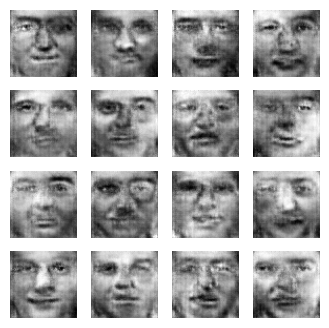

In [ ]:
@tf.function
def train_step(images):

    noise=tf.random.normal([BATCH,noise_dim])

    with tf.GradientTape() as gt, tf.GradientTape() as dt:

        fake=generator(noise,training=True)

        real_out=discriminator(images,training=True)
        fake_out=discriminator(fake,training=True)

        g_loss=loss_fn(tf.ones_like(fake_out),fake_out)

        real_labels = tf.ones_like(real_out) * 0.9   # smooth real labels
        fake_labels = tf.zeros_like(fake_out)

        d_loss = loss_fn(real_labels, real_out) + \
                loss_fn(fake_labels, fake_out)

    g_grad=gt.gradient(g_loss,generator.trainable_variables)
    d_grad=dt.gradient(d_loss,discriminator.trainable_variables)

    g_opt.apply_gradients(zip(g_grad,generator.trainable_variables))
    d_opt.apply_gradients(zip(d_grad,discriminator.trainable_variables))

for e in range(50):
    for batch in dataset_gan:
        train_step(batch)
    print("GAN Epoch",e)

# generate
noise=tf.random.normal([16,noise_dim])
gen=generator(noise)

plt.figure(figsize=(4,4))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow((gen[i].numpy().squeeze()+1)/2, cmap="gray")
    plt.axis("off")
plt.show()

This model implements a Deep Convolutional GAN (DCGAN) trained on the Olivetti Faces Dataset to generate synthetic face images from random noise. The generator takes a 100-dimensional noise vector and projects it through a dense layer into a low-resolution 8×8×256 feature map, which is then progressively upsampled using a series of Conv2DTranspose (deconvolution) layers with batch normalization and LeakyReLU activations. These layers increase spatial resolution (8×8 → 16×16 → 32×32 → 64×64) while reducing channel depth, producing a 64×64 grayscale image using a tanh activation where outputs are in the range [-1,1]. The discriminator acts as a binary classifier that takes either real images or generated images and processes them through successive convolutional layers with stride 2 (downsampling), LeakyReLU activations, and dropout for regularization, before flattening and outputting a single logit indicating real vs. fake. During training, the generator learns to fool the discriminator (using labels of 1 for fake images), while the discriminator is trained with label smoothing (real labels set to 0.9) to prevent overconfidence and improve stability.

In the generated images, the model has clearly learned the overall global structure of human faces. We can see consistent placement of eyes, noses, and general symmetry which shows that the adversarial training is working. However, the images still appear blurry and noisy, with visible grain and lack of fine detail. This is mainly due to the small dataset size and the inherent instability of GAN training, which makes it difficult for the generator to capture high-frequency features. Overall, the results suggest the model is in an intermediate stage of learning: it has captured coarse facial features but has not yet converged to producing sharp, high-quality images.